### Question 10

In [3]:
import numpy as np

prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]
])

# a) simple returns using slicing
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]
print("Returns shape:", returns.shape)

# b) annualised mean and std dev
ann_mean = np.mean(returns, axis=1) * 12
ann_std = np.std(returns, axis=1, ddof=1) * np.sqrt(12)
print("Annualised Mean:", ann_mean)
print("Annualised Std Dev:", ann_std)

# c) covariance matrix
cov_matrix = np.cov(returns)
print("\nCovariance Matrix:\n", cov_matrix)

Returns shape: (2, 11)
Annualised Mean: [0.39087388 0.20073826]
Annualised Std Dev: [0.20199403 0.14582022]

Covariance Matrix:
 [[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]


### Question 11

In [4]:
mu = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])
corr = np.array([
    [1.0, 0.4, 0.1], 
    [0.4, 1.0, 0.2], 
    [0.1, 0.2, 1.0]
])

# make the full covariance matrix
cov = np.outer(sigma, sigma) * corr

# a) equal weight portfolio
w_eq = np.array([1/3, 1/3, 1/3])
ret_eq = w_eq @ mu
var_eq = w_eq @ cov @ w_eq

# b) 10000 random portfolios
np.random.seed(42)
weights = np.random.dirichlet(np.ones(3), size=10000)
port_returns = weights @ mu

# vectorised variance without any loops
port_vars = np.einsum('ij,jk,ik->i', weights, cov, weights)
port_stds = np.sqrt(port_vars)

# c) sharpe ratio
rf = 0.04
sharpes = (port_returns - rf) / port_stds
max_idx = np.argmax(sharpes)
best_sharpe = sharpes[max_idx]
best_weights = weights[max_idx]

print("Best Sharpe:", best_sharpe)
print("Best Weights:", best_weights)

Best Sharpe: 0.5052923321966607
Best Weights: [0.20343152 0.17148749 0.62508099]


### Question 12

In [5]:
w1, w2 = 0.6, 0.4
sig1, sig2 = 0.20, 0.10

# a) 200 correlation values
rho = np.linspace(-1, 1, 200)
port_stds_rho = np.sqrt((w1*sig1)**2 + (w2*sig2)**2 + 2*w1*w2*rho*sig1*sig2)

# b) minimum risk
min_idx = np.argmin(port_stds_rho)
min_rho = rho[min_idx]
min_std = port_stds_rho[min_idx]

print("Min risk is at rho:", min_rho)
print("Minimum risk:", min_std)

# (c) Analytical proof
# If we look at the formula inside the square root, rho is just multiplied by positive numbers (2, w1, w2, sig1, sig2). 
# This means as rho goes up, the whole value goes up. To get the smallest value, we just need to pick the smallest possible rho, which is the boundary at -1.

Min risk is at rho: -1.0
Minimum risk: 0.08


### Question 13 & 14 (Pandas)

In [6]:
import pandas as pd

# given setup
np.random.seed(0)
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates, columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

# 13
# a) weekly simple returns
df_returns = df.pct_change().dropna()
print("First 3 rows of returns:\n", df_returns.head(3))

# b) stats
stats = df_returns.describe()
print("\nStats:\n", stats)

# c) annualised sharpe (weekly rf = 2% / 52)
rf_weekly = 0.02 / 52
sharpe_annualised = ((df_returns.mean() - rf_weekly) / df_returns.std()) * np.sqrt(52)
print("\nAnnualised Sharpe:\n", sharpe_annualised)

# 14
# a) correlation matrix
corr_matrix = df_returns.corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# b) equal weight portfolio return
weights_pd = pd.Series([0.25, 0.25, 0.25, 0.25], index=df_returns.columns)
port_ret_series = df_returns.dot(weights_pd)

# c) resample to monthly
monthly_series = port_ret_series.add(1).resample('ME').prod().sub(1)
print("\nMonthly Mean:", monthly_series.mean())
print("Monthly Std:", monthly_series.std())

First 3 rows of returns:
                 AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

Stats:
             AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269

Annualised Sharpe:
 AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64

Correlation Matrix:
            AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.0012

### Question 15 (Matplotlib)

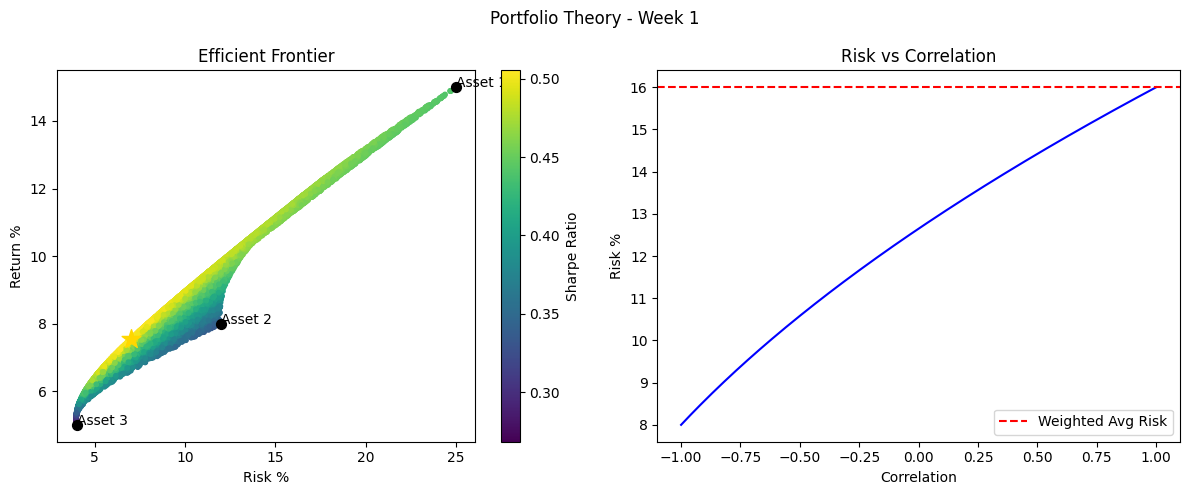

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Portfolio Theory - Week 1')

# Subplot 1: Efficient Frontier
# Plot all random portfolios
sc = ax1.scatter(port_stds * 100, port_returns * 100, c=sharpes, cmap='viridis', s=10)
plt.colorbar(sc, ax=ax1, label='Sharpe Ratio')

# Mark the best portfolio with a star
ax1.scatter(port_stds[max_idx] * 100, port_returns[max_idx] * 100, marker='*', color='gold', s=200)

# Mark the 3 single assets
tickers = ['Asset 1', 'Asset 2', 'Asset 3']
for i in range(3):
    ax1.scatter(sigma[i] * 100, mu[i] * 100, color='black', s=50)
    ax1.text(sigma[i] * 100, mu[i] * 100, tickers[i])

ax1.set_xlabel('Risk %')
ax1.set_ylabel('Return %')
ax1.set_title('Efficient Frontier')

# Subplot 2: Risk vs Correlation
ax2.plot(rho, port_stds_rho * 100, color='blue')

# Draw the line for the average risk
weighted_risk = (w1 * sig1 + w2 * sig2) * 100
ax2.axhline(weighted_risk, color='red', linestyle='--', label='Weighted Avg Risk')

ax2.set_xlabel('Correlation')
ax2.set_ylabel('Risk %')
ax2.set_title('Risk vs Correlation')
ax2.legend()

# Save and show
plt.tight_layout()
plt.savefig('week1_plots.png')
plt.show()